### **[The Rubber Band Effect: Understanding Stock Price Movements through Moving Averages](https://medium.com/@michael.wai/d3a64584dde9)**

> *Does moving averages create elasticity effect on stock prices?*

In [1]:
import sys

import warnings
warnings.filterwarnings('ignore')

IN_COLAB = 'google.colab' in sys.modules

from IPython.display import display
from datetime import datetime, date

import yfinance as yf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import argrelextrema

from sklearn.preprocessing import MinMaxScaler

from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.utils import plot_model

np.random.seed(42)
np.set_printoptions(suppress=True, precision=3)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1500)
pd.set_option('display.expand_frame_repr', False)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.precision', 3)

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['figure.dpi'] = 180

%autosave 20

Autosaving every 20 seconds


In [2]:
today = str(date.today())

# Define the stock ticker and the moving average period
ticker = 'AAPL'
ma_period = 200

# Fetch historical data for the last 2 years
stock_data = yf.download(ticker, period="5y", progress=False, multi_level_index=False)
if len(stock_data) < ma_period:
  sys.exit(f'Data size too small for {ticker}, program aborted.')

# Calculate the xx-day Moving Average (x_day_MA)
stock_data['x_day_MA'] = stock_data['Close'].rolling(window=ma_period).mean()

# Adjust the percentage over/under x-MA calculation
stock_data['Pct_Over_MA'] = (stock_data['Close'] - stock_data['x_day_MA']) / stock_data['x_day_MA'] * 100

# Handle NaN values
stock_data['Pct_Over_MA'].fillna(0, inplace=True)

display(stock_data.tail(10))

,Close,High,Low,Open,Volume,x_day_MA,Pct_Over_MA
Date,,,,,,,
2026-06-10,291.580,294.750,287.380,290.740,52793300,265.799,9.700
2026-06-11,295.630,297.000,289.590,293.720,42572500,266.144,11.079
2026-06-12,291.130,297.140,289.620,296.030,38742100,266.456,9.260
2026-06-15,296.420,297.780,291.700,294.120,45732600,266.789,11.106
2026-06-16,299.240,300.480,293.970,295.250,39874400,267.126,12.022
2026-06-17,295.950,302.070,294.360,300.850,42745100,267.448,10.657
2026-06-18,298.010,300.570,295.620,298.110,85962200,267.793,11.284
2026-06-22,297.010,302.420,296.760,297.310,44879900,268.089,10.788
2026-06-23,294.300,301.640,294.180,297.540,51936200,268.365,9.664


In [3]:
# Prepare data for neural network
def prepare_data(stock_data, ma_period):
  X = []
  for i in range(ma_period, len(stock_data)):
    X.append(stock_data['Pct_Over_MA'].iloc[i-ma_period:i].values)
  X = np.array(X)

  # Normalize the data
  scaler = MinMaxScaler(feature_range=(0, 1))
  X = scaler.fit_transform(X)

  return X

# Create the neural network model
def build_model(input_dim):
  model = Sequential()
  model.add(Dense(200, input_dim=input_dim, activation='relu', kernel_regularizer='l2'))
  model.add(Dropout(0.3))
  model.add(Dense(10, activation='relu', kernel_regularizer='l2'))
  model.add(Dropout(0.3))
  model.add(Dense(2, activation='linear'))  # Two outputs: window_peak and window_trough
  model.compile(optimizer='adam', loss='mse')
  plot_model(model, to_file='model_plot.png', show_shapes=True, show_layer_names=True)
  return model

# Prepare the data
X = prepare_data(stock_data, ma_period)
display(X[:5])

array([[0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484,
        0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484,
        0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484,
        0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484,
        0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484,
        0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484,
        0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484,
        0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484,
        0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484,
        0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484,
        0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484,
        0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484,
        0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484,
        0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484, 0.484,
      

In [4]:
# Split the data into training and testing sets
split_index = int(0.5 * len(X))  # 50/50 training vs testing data
X_train, X_test = X[:split_index], X[split_index:]

# Target values (y) are not predefined; the model will attempt to learn the best window_peak and window_trough
y_train = np.random.rand(len(X_train), 2) * 30  # Random values between 0 and 30
y_test = np.random.rand(len(X_test), 2) * 30

# Build and train the model
model = build_model(X_train.shape[1])
history = model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=1, validation_split=0.2)

# Make predictions
predictions = model.predict(X_test)

Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 203.6140 - val_loss: 86.1444
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 122.8219 - val_loss: 123.6061
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 128.0540 - val_loss: 86.6622
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 117.0880 - val_loss: 87.9457
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 116.1929 - val_loss: 100.4430
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 113.9310 - val_loss: 94.4379
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 112.6352 - val_loss: 106.3709
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 105.9722 - val_loss: 103.8675
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 108.8935 - val_loss: 107.2543
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 97.4246 - val_loss: 130.0827
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 102.0776 - val_loss: 115.5564
Epoch 12/50
14/14 ━━━━━━━━━

In [5]:
# Safeguard against NaNs in predictions
def safe_convert_to_int(value):
  if np.isnan(value) or value <= 0:
    return 1  # Default to a safe value
  else:
    return int(value)

best_window_peak = safe_convert_to_int(predictions[-1][0])
best_window_trough = safe_convert_to_int(predictions[-1][1])

# Find local maxima and minima using the predicted optimal windows
local_maxima = argrelextrema(stock_data['Pct_Over_MA'].values, comparator=np.greater, order=best_window_peak)[0]
local_minima = argrelextrema(stock_data['Pct_Over_MA'].values, comparator=np.less, order=best_window_trough)[0]

# Extract peak and trough values
peak_values = stock_data['Pct_Over_MA'].iloc[local_maxima]
trough_values = stock_data['Pct_Over_MA'].iloc[local_minima]

In [6]:
# Initialize positions array
positions = np.zeros(len(stock_data))

# Define buy and sell signals based on local minima and maxima
for i in range(1, len(stock_data)):
  if i in local_minima:
    positions[i] = 1  # Buy
  elif i in local_maxima:
    positions[i] = -1  # Sell

# Calculate log returns for buy and hold
stock_data['Log_Return_BnH'] = np.log(stock_data['Close'] / stock_data['Close'].shift(1))

# Initialize strategy returns with zeros (log returns start at 0)
strategy_log_returns = np.zeros_like(stock_data['Close'].values)

In [7]:
in_position = False
buy_price = 0

for i in range(1, len(stock_data)):
  if positions[i] == 1 and not in_position:
    # Buy at the closing price
    buy_price = stock_data['Close'].iloc[i]
    in_position = True
    strategy_log_returns[i] = strategy_log_returns[i-1]  # Carry forward previous return
  elif positions[i] == -1 and in_position:
    # Sell at the closing price
    sell_price = stock_data['Close'].iloc[i]
    # Calculate the log return for the sell action
    strategy_log_returns[i] = strategy_log_returns[i-1] + np.log(sell_price / buy_price)
    in_position = False
  elif in_position:
    # Update log returns while holding the position
    current_price = stock_data['Close'].iloc[i]
    daily_log_return = np.log(current_price / stock_data['Close'].iloc[i-1])
    strategy_log_returns[i] = strategy_log_returns[i-1] + daily_log_return
  else:
    # Carry forward the previous return if not in position
    strategy_log_returns[i] = strategy_log_returns[i-1]

# Calculate cumulative log returns for buy and hold strategy
stock_data['Cumulative_Log_Return_BnH'] = stock_data['Log_Return_BnH'].cumsum()

# The log returns for the strategy are already cumulative (as we sum them up)
cumulative_strategy_log_returns = strategy_log_returns

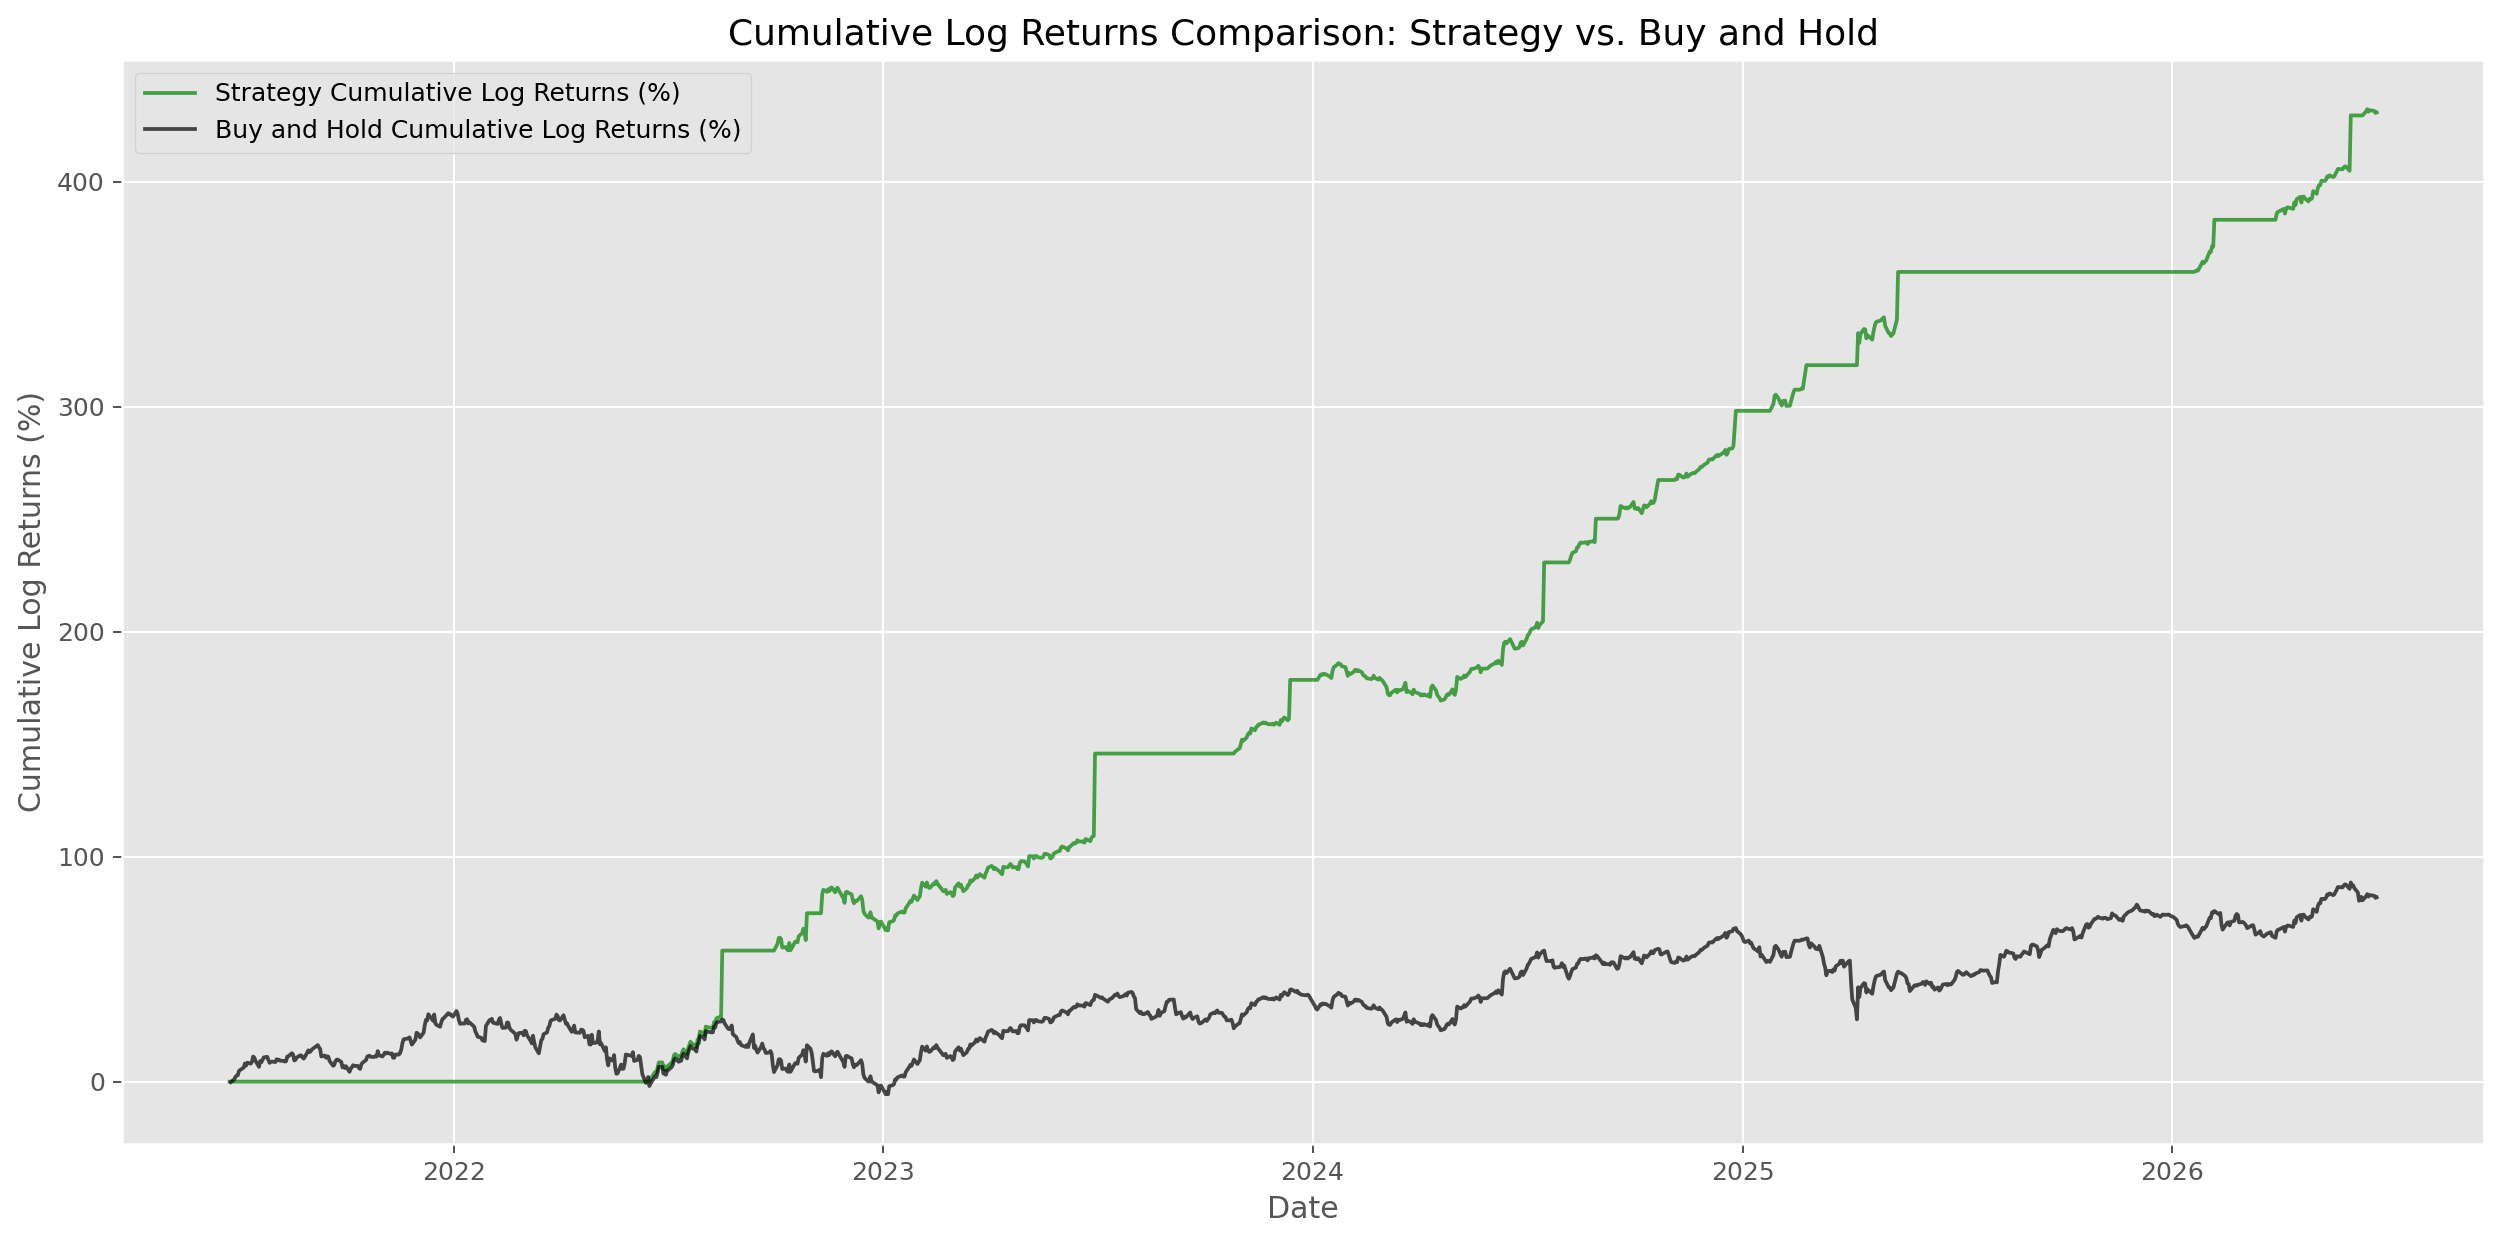

In [8]:
# Plot the results
fig = plt.figure(figsize=(14, 7))

# Plot cumulative log returns
plt.plot(stock_data.index, cumulative_strategy_log_returns * 100, label='Strategy Cumulative Log Returns (%)', color='green', alpha=0.7)
plt.plot(stock_data.index, stock_data['Cumulative_Log_Return_BnH'] * 100, label='Buy and Hold Cumulative Log Returns (%)', color='black', alpha=0.7)

plt.title('Cumulative Log Returns Comparison: Strategy vs. Buy and Hold')
plt.xlabel('Date')
plt.ylabel('Cumulative Log Returns (%)')
plt.legend()
plt.grid(True)

# Show the plot
plt.tight_layout()
plt.show()

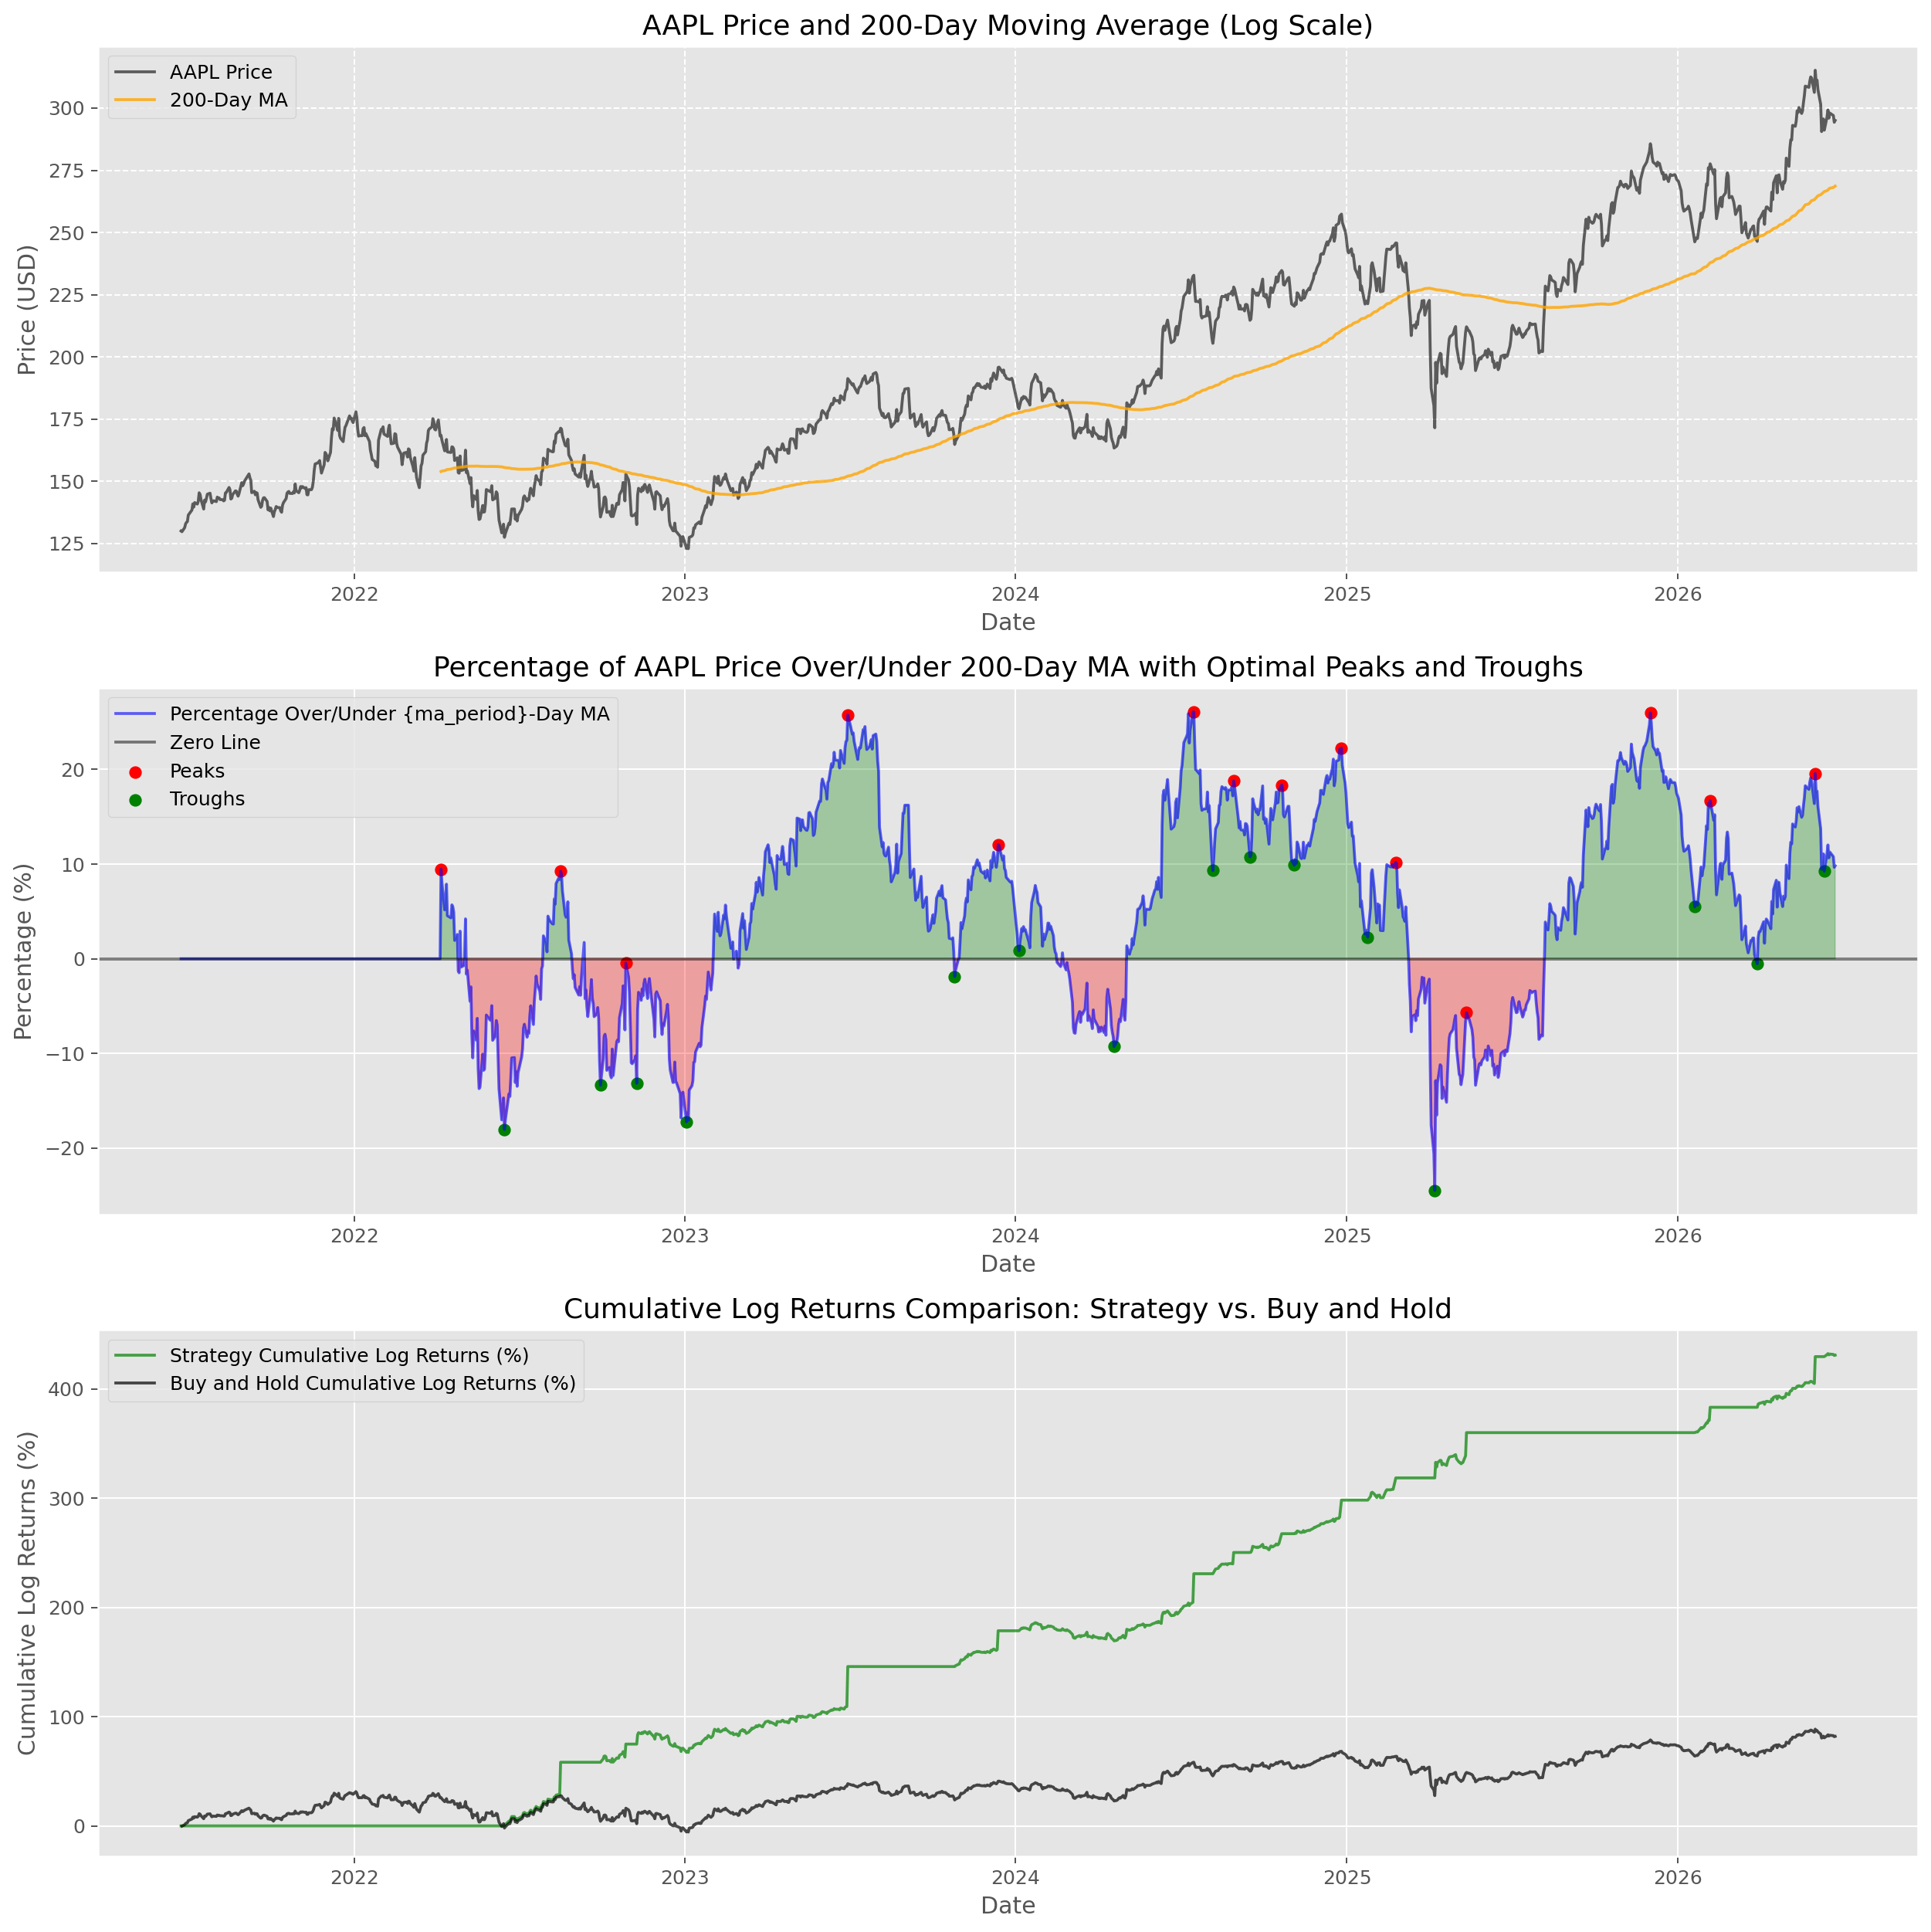

In [9]:
# Plot the results
fig = plt.figure(figsize=(14, 14))

# First subplot: Stock Price and x-Day MA
ax1 = plt.subplot(3, 1, 1)
plt.plot(stock_data.index, stock_data['Close'], label=f'{ticker} Price', color='black',alpha=0.6)
plt.plot(stock_data.index, stock_data['x_day_MA'], label=f'{ma_period}-Day MA', color='orange', alpha=0.8)
plt.title(f'{ticker} Price and {ma_period}-Day Moving Average (Log Scale)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, which="both", ls="--")

# Second subplot: Percentage Over/Under x-Day MA with Peaks and Troughs
ax2 = plt.subplot(3, 1, 2, sharex=ax1)
plt.plot(stock_data.index, stock_data['Pct_Over_MA'], label='Percentage Over/Under {ma_period}-Day MA', color='blue', alpha=0.6)
plt.axhline(y=0, color='black', linestyle='-', alpha=0.5, label=f'Zero Line')

# Fill green above 0 and red below 0
plt.fill_between(stock_data.index, stock_data['Pct_Over_MA'], where=(stock_data['Pct_Over_MA'] >= 0), color='green', alpha=0.3)
plt.fill_between(stock_data.index, stock_data['Pct_Over_MA'], where=(stock_data['Pct_Over_MA'] < 0), color='red', alpha=0.3)

plt.scatter(stock_data.index[local_maxima], peak_values, color='red', label='Peaks', marker='o')
plt.scatter(stock_data.index[local_minima], trough_values, color='green', label='Troughs', marker='o')
plt.title(f'Percentage of {ticker} Price Over/Under {ma_period}-Day MA with Optimal Peaks and Troughs')
plt.xlabel('Date')
plt.ylabel('Percentage (%)')
plt.legend()
plt.grid(True)

# Plot cumulative log returns
ax3 = plt.subplot(3, 1, 3, sharex=ax1)

plt.plot(stock_data.index, cumulative_strategy_log_returns * 100, label='Strategy Cumulative Log Returns (%)', color='green', alpha=0.7)
plt.plot(stock_data.index, stock_data['Cumulative_Log_Return_BnH'] * 100, label='Buy and Hold Cumulative Log Returns (%)', color='black', alpha=0.7)

plt.title('Cumulative Log Returns Comparison: Strategy vs. Buy and Hold')
plt.xlabel('Date')
plt.ylabel('Cumulative Log Returns (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()